In [ ]:
import pandas as pd
import os
from pathlib import Path

# Get all data files in the raw data folder
data_dir = Path("data/raw")
data_files = sorted(data_dir.glob("*.xls*"))

print(f"Found {len(data_files)} files in data/raw folder")
print("=" * 80)


In [ ]:
# List all files
from pathlib import Path


print("\nData files found:")
for i, file in enumerate[Path](data_files, 1):
    print(f"{i}. {file.name}")
    
print("\n" + "=" * 80)


In [ ]:
# Analyze DAT files (DAT20250713_1.xls format)
dat_files = [f for f in data_files if f.name.startswith('DAT')]
print(f"\nAnalyzing {len(dat_files)} DAT files...\n")

# Load first DAT file as sample with proper header parsing
sample_file = dat_files[0]
print(f"Sample file: {sample_file.name}")
print("=" * 80)

# Read header rows (row 0 = sensor group names, row 1 = measurement names)
df_raw = pd.read_excel(sample_file, engine='xlrd', header=None, nrows=2)
group_names = df_raw.iloc[0].values
measurement_names = df_raw.iloc[1].values

# Create proper column names by combining group and measurement with a dash
column_names = []
for group, measurement in zip(group_names, measurement_names):
    # Forward fill group names (they're only in the first column of each group)
    if pd.notna(group) and str(group).strip():
        current_group = str(group).strip()
    else:
        current_group = column_names[-1].split(' - ')[0] if column_names else 'Unknown'
    
    # Combine group and measurement with dash
    if pd.notna(measurement) and str(measurement).strip():
        column_names.append(f"{current_group} - {str(measurement).strip()}")
    else:
        # Fallback if measurement name is missing
        column_names.append(f"{current_group} - Column_{len(column_names)}")

# Read the actual data
df = pd.read_excel(sample_file, engine='xlrd', skiprows=2, names=column_names)

print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


In [ ]:
# Display column names organized by category
print("\n" + "-" * 100)
print("COLUMN CATEGORIES:")
print("-" * 100)

col_categories = {
    'Date_Time': [col for col in column_names if 'Date_Time' in col],
    'M/E PORT (Main Engine Port)': [col for col in column_names if 'M/E PORT' in col],
    'M/E STBD (Main Engine Starboard)': [col for col in column_names if 'M/E STBD' in col],
    'Shipboard GPS': [col for col in column_names if 'GPS' in col],
    'Shipboard AIS': [col for col in column_names if 'AIS' in col],
    'LC-2 PORT': [col for col in column_names if 'LC-2 PORT' in col],
    'LC-2 STBD': [col for col in column_names if 'LC-2 STBD' in col],
    'Shaft PORT': [col for col in column_names if 'Shaft PORT' in col],
    'Shaft STBD': [col for col in column_names if 'Shaft STBD' in col]
}

for category, cols in col_categories.items():
    if cols:
        print(f"\n{category}: ({len(cols)} columns)")
        for col in cols:
            print(f"  - {col}")


In [ ]:
# Display first few rows
print("\n" + "-" * 100)
print("FIRST 5 ROWS:")
print("-" * 100)
pd.set_option('display.max_columns', 8)
pd.set_option('display.width', 120)
print(df.head())


In [ ]:
# Data types summary
print("\n" + "-" * 100)
print("DATA TYPES SUMMARY:")
print("-" * 100)
type_counts = df.dtypes.value_counts()
for dtype, count in type_counts.items():
    print(f"{dtype}: {count} columns")


In [ ]:
# Basic statistics
print("\n" + "-" * 100)
print("BASIC STATISTICS (Numeric columns):")
print("-" * 100)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(df[numeric_cols].describe().T.head(15))

# Missing values
print("\n" + "-" * 100)
print("MISSING VALUES:")
print("-" * 100)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df.head(10))
else:
    print("✓ No missing values found!")


In [ ]:
# Analyze structure across all DAT files
print("\n" + "=" * 100)
print("CHECKING STRUCTURE ACROSS ALL DAT FILES")
print("=" * 100)

dat_info = []
for file in dat_files[:5]:  # Sample first 5 for performance
    try:
        df_temp = pd.read_excel(file, engine='xlrd', skiprows=2)
        dat_info.append({
            'File': file.name,
            'Rows': df_temp.shape[0],
            'Columns': df_temp.shape[1]
        })
    except Exception as e:
        dat_info.append({
            'File': file.name,
            'Rows': 0,
            'Columns': 0,
            'Error': str(e)[:50]
        })

summary_df = pd.DataFrame(dat_info)
print("\nSample of DAT Files (first 5):")
print(summary_df.to_string(index=False))
if len(dat_files) > 5:
    print(f"\n... and {len(dat_files) - 5} more DAT files")


In [ ]:
# Analyze other files
print("\n" + "=" * 100)
print("ANALYZING OTHER FILES")
print("=" * 100)
other_files = [f for f in data_files if not f.name.startswith('DAT')]

for file in other_files:
    print(f"\n{'='*80}")
    print(f"File: {file.name}")
    print('='*80)
    try:
        df_other = pd.read_excel(file, engine='openpyxl')
        print(f"Shape: {df_other.shape[0]:,} rows × {df_other.shape[1]} columns")
        print(f"\nColumn names ({len(df_other.columns)}):")
        for i, col in enumerate(df_other.columns[:25], 1):
            print(f"{i:2d}. {col}")
        if len(df_other.columns) > 25:
            print(f"   ... and {len(df_other.columns) - 25} more columns")
        print(f"\nFirst 3 rows:")
        print(df_other.head(3))
    except Exception as e:
        print(f"Error reading file: {e}")


In [ ]:
# Comprehensive Summary
print("\n" + "=" * 100)
print("COMPREHENSIVE DATA SUMMARY")
print("=" * 100)

print(f"\nTotal files found: {len(data_files)}")
print(f"  - DAT files: {len(dat_files)}")
print(f"  - Other files: {len(other_files)}")

print(f"\nSample DAT file analysis ({sample_file.name}):")
print(f"  - Total rows: {df.shape[0]:,}")
print(f"  - Total columns: {df.shape[1]}")
print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  - Data types: {type_counts.to_dict()}")

print("\nKey findings:")
print("  - DAT files contain time-series data with 1-second intervals")
print("  - Data includes: Main Engine (PORT/STBD), GPS, AIS, LC-2 sensors, Shaft measurements")
print("  - Each DAT file covers approximately 12 hours of data (43,200 seconds)")

print("\n✓ Analysis complete!")


In [ ]:
# Print column names for first 2 datasets to verify the combined headers
print("\n" + "=" * 100)
print("COLUMN NAMES FOR FIRST 2 DATASETS (to verify combined headers)")
print("=" * 100)

for i, file in enumerate(dat_files[:2], 1):
    print(f"\n{'='*80}")
    print(f"Dataset {i}: {file.name}")
    print('='*80)
    
    # Read header rows
    df_raw = pd.read_excel(file, engine='xlrd', header=None, nrows=2)
    group_names = df_raw.iloc[0].values
    measurement_names = df_raw.iloc[1].values
    
    # Create column names
    col_names = []
    for group, measurement in zip(group_names, measurement_names):
        if pd.notna(group) and str(group).strip():
            current_group = str(group).strip()
        else:
            current_group = col_names[-1].split(' - ')[0] if col_names else 'Unknown'
        
        if pd.notna(measurement) and str(measurement).strip():
            col_names.append(f"{current_group} - {str(measurement).strip()}")
        else:
            col_names.append(f"{current_group} - Column_{len(col_names)}")
    
    # Print sensor grouped columns
    sensor_groups = {
    'M/E PORT': (0, 10),
    'M/E STBD': (11, 20),
    'Shipboard GPS': (21, 24),
    'Shipboard AIS': (25, 33),
    'LC-2 PORT': (34, 36),
    'LC-2 STBD': (37, 39),
    'Shaft PORT': (40, 47),
    'Shaft STBD': (48, 50)
}
    
    for group_name, (start_col, end_col) in sensor_groups.items():
        print(f"\n{group_name} (columns {start_col}-{end_col}):")
        for idx in range(start_col, min(end_col + 1, len(col_names))):
            print(f"  [{idx:2d}] {col_names[idx]}")


In [ ]:
# Helper function to combine headers from multi-row header
def get_combined_columns(file_path):
    """Read first two rows and combine them with a dash."""
    df_raw = pd.read_excel(file_path, engine='xlrd', header=None, nrows=2)
    group_names = df_raw.iloc[0].values
    measurement_names = df_raw.iloc[1].values
    
    column_names = []
    for group, measurement in zip(group_names, measurement_names):
        if pd.notna(group) and str(group).strip():
            current_group = str(group).strip()
        else:
            current_group = column_names[-1].split(' - ')[0] if column_names else 'Unknown'
        
        if pd.notna(measurement) and str(measurement).strip():
            column_names.append(f"{current_group} - {str(measurement).strip()}")
        else:
            column_names.append(f"{current_group} - Column_{len(column_names)}")
    
    return column_names

# Group DAT files by date
print("\n" + "=" * 100)
print("CONCATENATING DAILY DAT FILES")
print("=" * 100)

from collections import defaultdict

# Group files by date
date_groups = defaultdict(list)
for file in dat_files:
    if file.name.startswith('DAT'):
        # Extract date from filename (DATYYYYMMDD_N.xls)
        parts = file.stem.split('_')
        if len(parts) == 2:
            date_part = parts[0].replace('DAT', '')
            date_groups[date_part].append(file)

print(f"\nFound {len(date_groups)} dates with DAT files:")
for date, files in sorted(date_groups.items()):
    print(f"  {date}: {len([f for f in files if '_1' in f.name])} files (_1 and _2)")

print("\n" + "-" * 100)


In [ ]:
# Process each date and concatenate _1 and _2 files
concatenation_summary = []

for date in sorted(date_groups.keys()):
    files = date_groups[date]
    
    # Find _1 and _2 files for this date
    file_1 = next((f for f in files if '_1' in f.name), None)
    file_2 = next((f for f in files if '_2' in f.name), None)
    
    if file_1 is None or file_2 is None:
        print(f"\n⚠ Skipping date {date}: missing _1 or _2 file")
        continue
    
    print(f"\nProcessing date {date}:")
    print(f"  - File 1: {file_1.name}")
    print(f"  - File 2: {file_2.name}")
    
    try:
        # Get combined column names from the first file
        column_names = get_combined_columns(file_1)
        
        # Read both files with combined headers
        df1 = pd.read_excel(file_1, engine='xlrd', skiprows=2, names=column_names)
        df2 = pd.read_excel(file_2, engine='xlrd', skiprows=2, names=column_names)
        
        print(f"  - File 1: {df1.shape[0]:,} rows")
        print(f"  - File 2: {df2.shape[0]:,} rows")
        
        # Concatenate vertically
        df_combined = pd.concat([df1, df2], ignore_index=True)
        print(f"  - Combined: {df_combined.shape[0]:,} rows × {df_combined.shape[1]} columns")
        
        # Save to CSV
        output_file = data_dir / f"DAT{date}.csv"
        df_combined.to_csv(output_file, index=False)
        print(f"  - ✓ Saved to: {output_file.name}")
        
        # Store summary
        concatenation_summary.append({
            'Date': date,
            'File 1 Rows': df1.shape[0],
            'File 2 Rows': df2.shape[0],
            'Combined Rows': df_combined.shape[0],
            'Columns': df_combined.shape[1],
            'Output File': output_file.name
        })
        
    except Exception as e:
        print(f"  - ✗ Error processing {date}: {e}")
        concatenation_summary.append({
            'Date': date,
            'Error': str(e)[:50]
        })

print("\n" + "=" * 100)
print("CONCATENATION COMPLETE")
print("=" * 100)


In [ ]:
# Display summary of concatenated files
print("\nSUMMARY OF CONCATENATED FILES:")
print("=" * 100)

summary_df = pd.DataFrame(concatenation_summary)
print(summary_df.to_string(index=False))

print("\n" + "=" * 100)
print(f"✓ Successfully concatenated {len([s for s in concatenation_summary if 'Error' not in s])} date pairs")
print(f"✓ CSV files saved in: {data_dir}")
print("=" * 100)


In [ ]:
import pandas as pd

df_csv = pd.read_csv("data/raw/DAT20250713.csv")

# Display all columns and their types
for col, dtype in zip(df_csv.columns, df_csv.dtypes):
    print(f"{col}: {dtype}")


In [ ]:
import pandas as pd

# Load merged dataset
df = pd.read_csv("data/raw/DAT20250713.csv")

# Convert datetime if not already
df['Date_Time - Column_0'] = pd.to_datetime(df['Date_Time - Column_0'])

# Find the last row before noon
last_before_noon = df[df['Date_Time - Column_0'] <= '2025-07-13 11:59:59'].tail(1)

# Find the first row after noon
first_after_noon = df[df['Date_Time - Column_0'] >= '2025-07-13 12:00:00'].head(1)

print("Last record before 12:00:", last_before_noon)
print("\nFirst record at or after 12:00:", first_after_noon)


In [ ]:
df['time_diff'] = df['Date_Time - Column_0'].diff().dt.total_seconds()
print(df['time_diff'].value_counts())


In [ ]:
gap_rows = df[df['time_diff'] != 1.0]
print(gap_rows)


In [ ]:
print(df.columns)

In [ ]:
# Drop duplicate timestamp
df = df.drop_duplicates(subset='Date_Time - Column_0', keep='first')

# Optional: reindex to 1-second intervals and interpolate
df['Date_Time - Column_0'] = pd.to_datetime(df['Date_Time - Column_0'])
df = df.set_index('Date_Time - Column_0').asfreq('1s')
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].interpolate()


In [ ]:

gap_rows = df[df['time_diff'] != 1.0]
print(gap_rows)


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/raw/DAT20250713.csv")

# Ensure Date_Time column is datetime
df['Date_Time - Column_0'] = pd.to_datetime(df['Date_Time - Column_0'])

# Set datetime as index for convenience
df = df.set_index('Date_Time - Column_0')

# Compute time differences between consecutive rows
df['time_diff'] = df.index.to_series().diff().dt.total_seconds()

# 1. Duplicated timestamps (time_diff == 0)
duplicates = df[df['time_diff'] == 0]

# 2. Missing seconds (time_diff > 1)
missing = df[df['time_diff'] > 1]

print("Duplicated timestamps:")
print(duplicates)

print("\nMissing seconds:")
print(missing)


In [ ]:
import pandas as pd
from pathlib import Path

# Folder containing merged DAT CSV files
data_dir = Path("data/raw")
output_dir = Path("data/processed")
output_dir.mkdir(exist_ok=True, parents=True)

# List all merged DAT CSVs
csv_files = list(data_dir.glob("DAT*.csv"))

for file_path in csv_files:
    print(f"Processing {file_path.name}...")
    
    # Load CSV
    df = pd.read_csv(file_path)
    
    # Ensure Date_Time column is datetime
    df['Date_Time - Column_0'] = pd.to_datetime(df['Date_Time - Column_0'], errors='coerce')
    
    # Drop rows with invalid or NaT datetimes
    df = df.dropna(subset=['Date_Time - Column_0'])
    
    # Set datetime as index
    df = df.set_index('Date_Time - Column_0')
    
    # Drop exact duplicate timestamps
    df = df[~df.index.duplicated(keep='first')]
    
    # Reindex to continuous 1-second frequency
    df = df.asfreq('1s')
    
    # Interpolate all numeric columns to fill missing rows
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = df[numeric_cols].interpolate(method='linear')
    
    # Optional: forward-fill integer columns that shouldn't be fractional
    int_cols = df.select_dtypes(include=['int64']).columns
    df[int_cols] = df[int_cols].round(0).astype('Int64')  # nullable integer type
    
    # Reset index to keep Date_Time as a column
    df = df.reset_index()
    
    # Save cleaned CSV
    out_file = output_dir / file_path.name
    df.to_csv(out_file, index=False, date_format='%Y-%m-%d %H:%M:%S', float_format='%.6f')
    
    # Report summary
    print(f"Saved cleaned file: {out_file.name}")
    print(f"  Total rows: {len(df)}")
    print(f"  Duplicates removed: {len(df[df.duplicated(subset=['Date_Time - Column_0'])])}")
    print(f"  Any missing seconds? {df['Date_Time - Column_0'].diff().dt.total_seconds().max() > 1}\n")


#Cleaning For OSG and ZOR

In [ ]:
import pandas as pd
from pathlib import Path

# ----------------------------
# Setup
# ----------------------------
raw_dir = Path("data/raw")
processed_dir = Path("data/processed")
processed_dir.mkdir(exist_ok=True, parents=True)

osg_file = raw_dir / "OSG - Raw Data_13au20juil2025.xlsx"
zor_file = raw_dir / "ZOR001_BC_10Oct2025_Test_25Oct2025.xlsx"

# ----------------------------
# Clean OSG Dataset
# ----------------------------
def clean_osg(file_path):
    print(f"\nCleaning OSG dataset: {file_path.name}")
    df = pd.read_excel(file_path, engine="openpyxl")

    # Standardize column names
    df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")
    
    # Convert Date column to datetime
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    # Drop rows with no date
    df = df.dropna(subset=["Date"])

    # Drop fully empty rows or duplicates
    df = df.dropna(how="all").drop_duplicates()

    # Fill missing Voyage_Zone if needed
    if "Voyage_Zone" in df.columns:
        df["Voyage_Zone"] = df["Voyage_Zone"].fillna("Unknown")

    # Sort by Date and reset index
    df = df.sort_values("Date").reset_index(drop=True)

    # Save cleaned file
    out_path = processed_dir / "OSG_Cleaned.csv"
    df.to_csv(out_path, index=False, date_format="%Y-%m-%d %H:%M:%S")
    print(f"Saved cleaned OSG data to: {out_path}")
    print(f"   Rows: {len(df)}, Columns: {len(df.columns)}")

    return df

# ----------------------------
# Clean ZOR Dataset
# ----------------------------
def clean_zor(file_path):
    print(f"\nCleaning ZOR dataset: {file_path.name}")
    df = pd.read_excel(file_path, engine="openpyxl")

    # Standardize column names
    df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

    # Convert relevant date fields to datetime
    date_cols = [
        "Date_de_fin_réelle", "Début_réel", "DF_réelle", 
        "Début_manœuvre", "Fin_manœuvre"
    ]
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # Remove rows missing essential fields
    if "Désignation" in df.columns:
        df = df.dropna(subset=["Désignation"])
    
    # Fill common missing values
    df = df.fillna({
        "Saison": "Unknown",
        "Type_d'activité": "Unknown",
        "Région": "Unknown",
        "Port": "Unknown",
        "Déglacage": "Unknown"
    })

    # Sort by "Début_réel" if present
    if "Début_réel" in df.columns:
        df = df.sort_values("Début_réel").reset_index(drop=True)

    # Drop duplicates
    df = df.drop_duplicates()

    # Save cleaned file
    out_path = processed_dir / "ZOR_Cleaned.csv"
    df.to_csv(out_path, index=False, date_format="%Y-%m-%d %H:%M:%S")
    print(f" Saved cleaned ZOR data to: {out_path}")
    print(f"   Rows: {len(df)}, Columns: {len(df.columns)}")

    return df

# ----------------------------
# Run cleaning
# ----------------------------
df_osg_clean = clean_osg(osg_file)
df_zor_clean = clean_zor(zor_file)

print("\nCleaning complete for both datasets!")


In [ ]:
import pandas as pd
from pathlib import Path

# --------------------------
# Project-relative paths
# --------------------------
base_dir = Path("data")
processed_dir = base_dir / "processed"
raw_dir = base_dir / "raw"

# DAT files (already cleaned)
dat_files = sorted(processed_dir.glob("DAT*.csv"))
osg_file = processed_dir / "OSG_Cleaned.csv"

# Output files
dat_1min_file = processed_dir / "DAT_1min.csv"
merged_file = processed_dir / "Integrated_OSG_DAT.csv"

# --------------------------
# Load and combine all DATs
# --------------------------
def load_all_dat(files):
    dfs = []
    for f in files:
        print(f"Loading {f.name} ...")
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()

        # Find datetime column
        time_col = [c for c in df.columns if "Date_Time" in c or "Date" in c][0]
        df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
        df = df.dropna(subset=[time_col])
        df = df.sort_values(time_col)
        df = df.set_index(time_col)
        dfs.append(df)

    combined = pd.concat(dfs)
    print(f"\nCombined DAT shape: {combined.shape}\n")
    return combined

# --------------------------
#  Resample DAT to 1 minute and fill missing timestamps
# --------------------------
def resample_to_1min(dat_df):
    print("Resampling DAT data from 1 second → 1 minute ...")
    numeric_cols = dat_df.select_dtypes(include=["float64", "int64"]).columns

    # Aggregation: sums for totals, mean for others
    agg_dict = {col: "mean" for col in numeric_cols}
    for col in numeric_cols:
        if any(k in col for k in ["Total", "Energy", "Flowrate"]):
            agg_dict[col] = "sum"

    dat_1min = dat_df.resample("1min").agg(agg_dict)

    # Reindex to continuous 1-minute range to fill missing timestamps
    full_index = pd.date_range(start=dat_1min.index.min(), end=dat_1min.index.max(), freq="1min")
    dat_1min = dat_1min.reindex(full_index)

    # Interpolate missing numeric values
    dat_1min[numeric_cols] = dat_1min[numeric_cols].interpolate(method="linear")

    dat_1min.to_csv(dat_1min_file, float_format="%.6f", date_format="%Y-%m-%d %H:%M:%S")
    print(f"Saved 1-minute DAT data → {dat_1min_file}")
    return dat_1min

# --------------------------
#  Merge DAT with OSG using left join
# --------------------------
def merge_with_osg(dat_1min, osg_path):
    print("\nMerging with OSG data ...")
    osg = pd.read_csv(osg_path)
    osg.columns = osg.columns.str.strip()

    # Find datetime column in OSG
    time_col_osg = [c for c in osg.columns if "Date" in c][0]
    osg[time_col_osg] = pd.to_datetime(osg[time_col_osg], errors="coerce")
    osg = osg.set_index(time_col_osg)

    # Left join: keep all DAT timestamps
    merged = dat_1min.merge(osg, how="left", left_index=True, right_index=True)

    # Interpolate numeric columns from OSG if missing
    numeric_cols_osg = osg.select_dtypes(include=["float64", "int64"]).columns
    for col in numeric_cols_osg:
        if col in merged.columns:
            merged[col] = merged[col].interpolate(method="linear")

    merged.to_csv(merged_file, float_format="%.6f", date_format="%Y-%m-%d %H:%M:%S")
    print(f"Saved integrated dataset → {merged_file}")
    return merged

# --------------------------
#  Main
# --------------------------
if __name__ == "__main__":
    if not dat_files:
        raise FileNotFoundError(f"No DAT files found in {processed_dir}")

    dat_df = load_all_dat(dat_files)
    dat_1min = resample_to_1min(dat_df)
    merged_df = merge_with_osg(dat_1min, osg_file)

    print("\nIntegration complete! Ready for analysis.")


In [ ]:
import pandas as pd

# --------------------------
# Load integrated dataset
# --------------------------
merged_file = "data/processed/Integrated_OSG_DAT.csv"
df = pd.read_csv(merged_file, parse_dates=[0])  # assuming first column is datetime

# --------------------------
#  Check datetime alignment
# --------------------------
time_diff = df.iloc[:,0].diff().dt.total_seconds().unique()
print("Unique time differences (seconds):", time_diff)
if all(time_diff[1:] == 60):
    print("✅ Time alignment looks good (1-minute intervals).")
else:
    print("⚠️ There might be missing or duplicated timestamps!")

# --------------------------
#  Check row count
# --------------------------
print(f"\nTotal rows: {len(df)}")

# --------------------------
#  Spot check some timestamps
# --------------------------
sample_times = ["2025-07-13 12:00:00", "2025-07-15 08:15:00"]
print("\nSpot check for sample timestamps:")
print(df[df.iloc[:,0].isin(pd.to_datetime(sample_times))])

# --------------------------
#  Check for missing/NaN values
# --------------------------
missing = df.isna().sum()
print("\nMissing values per column:")
print(missing[missing>0] if missing.any() else "✅ No missing values detected.")

# --------------------------
# Quick statistics for numeric columns
# --------------------------
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
print("\nSummary statistics for numeric columns:")
print(df[numeric_cols].describe())


In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# --------------------------
# 📁 Project paths
# --------------------------
base_dir = Path("data")
processed_dir = base_dir / "processed"

# Merged dataset
merged_file = processed_dir / "Integrated_OSG_DAT.csv"

# Output final cleaned dataset
final_clean_file = processed_dir / "Integrated_OSG_DAT_Cleaned.csv"

# --------------------------
# ⚙️ Load merged dataset
# --------------------------
merged_df = pd.read_csv(merged_file, parse_dates=[0])
merged_df.columns = merged_df.columns.str.strip()
time_col = merged_df.columns[0]  # assuming first column is datetime
merged_df[time_col] = pd.to_datetime(merged_df[time_col], errors="coerce")
merged_df = merged_df.dropna(subset=[time_col])
merged_df = merged_df.set_index(time_col)

print(f"\nLoaded merged dataset: {merged_df.shape} rows x {merged_df.shape[1]} columns")

# --------------------------
# ⚙️ Handle missing categorical values
# --------------------------
cat_cols = ['Ship_Name','Operation_Mode','Voyage_Zone']
for col in cat_cols:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].fillna(method='ffill')

print("\n✅ Missing categorical values forward-filled")

# --------------------------
# ⚙️ Save fully cleaned merged dataset
# --------------------------
merged_df.reset_index().to_csv(final_clean_file, index=False, float_format="%.6f", date_format="%Y-%m-%d %H:%M:%S")
print(f"\n💾 Saved final cleaned dataset → {final_clean_file}")

# --------------------------
# ⚙️ Quick summary stats
# --------------------------
print("\n--- Numeric Summary ---")
numeric_cols = merged_df.select_dtypes(include=['float64', 'int64']).columns
print(merged_df[numeric_cols].describe())

# --------------------------
# ⚙️ Quick plots
# --------------------------
plt.figure(figsize=(12,6))
if 'M/E PORT - Total Fuel' in merged_df.columns:
    merged_df['M/E PORT - Total Fuel'].plot(title="M/E PORT Total Fuel Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Total Fuel")
    plt.show()

plt.figure(figsize=(12,6))
if 'Energy_Port (kWh)' in merged_df.columns:
    merged_df['Energy_Port (kWh)'].plot(title="Port Energy Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Energy (kWh)")
    plt.show()

plt.figure(figsize=(12,6))
if 'M/E PORT - Temperature' in merged_df.columns:
    merged_df['M/E PORT - Temperature'].plot(title="M/E PORT Temperature Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Temperature (°C)")
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

# --------------------------
# Ensure datetime index
# --------------------------
if 'Unnamed: 0' in merged_df.columns:
    merged_df = merged_df.set_index('Unnamed: 0')

merged_df.index = pd.to_datetime(merged_df.index)

# --------------------------
# Check time differences
# --------------------------
time_diffs = merged_df.index.to_series().diff().dt.total_seconds()
print("Unique time differences (seconds):", time_diffs.unique())

# --------------------------
# Spot check sample times
# --------------------------
sample_times = ['2025-07-13 12:00:00', '2025-07-15 08:15:00']
print("\nSample rows:")
print(merged_df.loc[sample_times])

# --------------------------
# Function to plot a variable with datetime x-axis
# --------------------------
def plot_series(df, column, title, ylabel=None):
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df[column], marker='.', linestyle='-', alpha=0.7)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel if ylabel else column)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --------------------------
# Port variables
# --------------------------
plot_series(merged_df, 'M/E PORT - Total Fuel', "M/E PORT Total Fuel", "Fuel (L)")
plot_series(merged_df, 'Energy_Port_kWh', "Port Energy", "Energy (kWh)")
plot_series(merged_df, 'M/E PORT - Temperature', "Port Temperature", "Temperature (°C)")

# --------------------------
# Starboard variables
# --------------------------
plot_series(merged_df, 'M/E STBD - Total Fuel', "M/E STBD Total Fuel", "Fuel (L)")
plot_series(merged_df, 'Energy_STBD_kWh', "STBD Energy", "Energy (kWh)")
plot_series(merged_df, 'M/E STBD - Temperature', "STBD Temperature", "Temperature (°C)")


In [ ]:
print(merged_df.columns.tolist())

In [ ]:
# Are there missing timestamps?
missing = merged_df.index.to_series().diff().dt.total_seconds().ne(60).sum()
print(f"Number of unexpected time steps (not 1-min apart): {missing}")

# Any duplicates?
duplicates = merged_df.index.duplicated().sum()
print(f"Number of duplicated timestamps: {duplicates}")


In [ ]:
vars_to_plot = [
    'M/E PORT - Total Fuel', 'Energy_Port_kWh', 'M/E PORT - Temperature',
    'M/E STBD - Total Fuel', 'Energy_STBD_kWh', 'M/E STBD - Temperature'
]

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(14, 3*len(vars_to_plot)), sharex=True)

for ax, col in zip(axes, vars_to_plot):
    ax.plot(merged_df.index, merged_df[col], marker='.', linestyle='-', alpha=0.7)
    ax.set_ylabel(col)
    ax.grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.savefig('data/saved_figures/Port_Fuel_vs_STBD_Fuel.png')
plt.show()


In [ ]:
plt.figure(figsize=(12,4))
plt.plot(merged_df.index, merged_df['M/E PORT - Total Fuel'], label='Port Fuel')
plt.plot(merged_df.index, merged_df['M/E STBD - Total Fuel'], label='STBD Fuel')
plt.title("Port vs Starboard Total Fuel")
plt.xlabel("Time")
plt.ylabel("Fuel (L)")
plt.legend()
plt.grid(True)
plt.savefig('data/saved_figures/Port_Fuel_vs_STBD_Fuel_lines.png')
plt.show()


In [ ]:
subset = merged_df['2025-07-15 00:00':'2025-07-15 12:00']
def plot_series(df, column, title, ylabel=None, show=False):
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(df.index, df[column], marker='.', linestyle='-', alpha=0.7)
    ax.set(title=title, xlabel="Time", ylabel=ylabel or column)
    ax.grid(True); fig.tight_layout()
    if show:
        plt.show()
    return fig, ax

subset = merged_df['2025-07-15 00:00':'2025-07-15 12:00']
fig, _ = plot_series(subset, 'M/E PORT - Total Fuel', "Port Fuel Zoom 15-Jul 00:00-12:00")
fig.savefig('data/saved_figures/Port_Fuel_Zoom_15-Jul_00:00-12:00.png')
plt.close(fig)

In [ ]:
corr = merged_df[['M/E PORT - Total Fuel', 'M/E STBD - Total Fuel', 'Energy_Port_kWh', 'Energy_STBD_kWh']].corr()
print(corr)


Unique time differences (seconds): [nan 60.]
Missing or irregular timestamps: 1
Duplicated timestamps: 0

Sample rows:
                     M/E PORT - Raw Supply Flowrate  M/E PORT - Raw Supply Total Fuel  \
Unnamed: 0                                                                              
2025-07-13 12:00:00                             0.0                      3.737101e+08   
2025-07-15 08:15:00                             0.0                      3.741335e+08   

                     M/E PORT - Raw Supply Temperature  M/E PORT - Raw Return Flowrate  ...  RPM_PORT  RPM_STBD  \
Unnamed: 0                                                                              ...                       
2025-07-13 12:00:00                          41.899994                             0.0  ...       0.0       0.0   
2025-07-15 08:15:00                          34.700012                             0.0  ...       0.0       0.0   

                     LC2_PORT_Oxygen_PORT  LC2_STBD_Oxygen_STBD

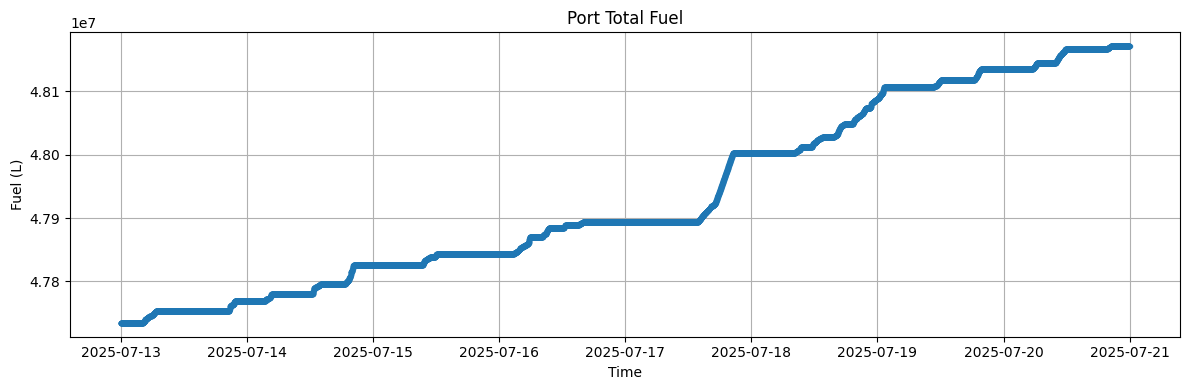

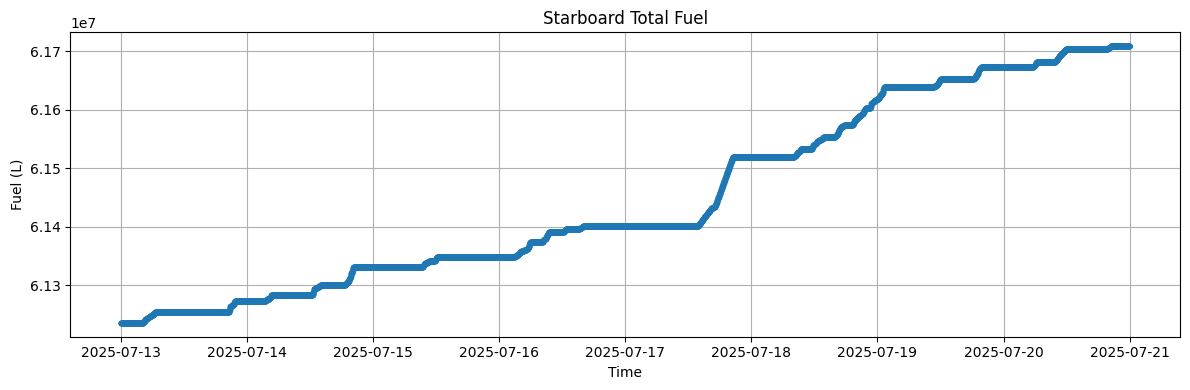

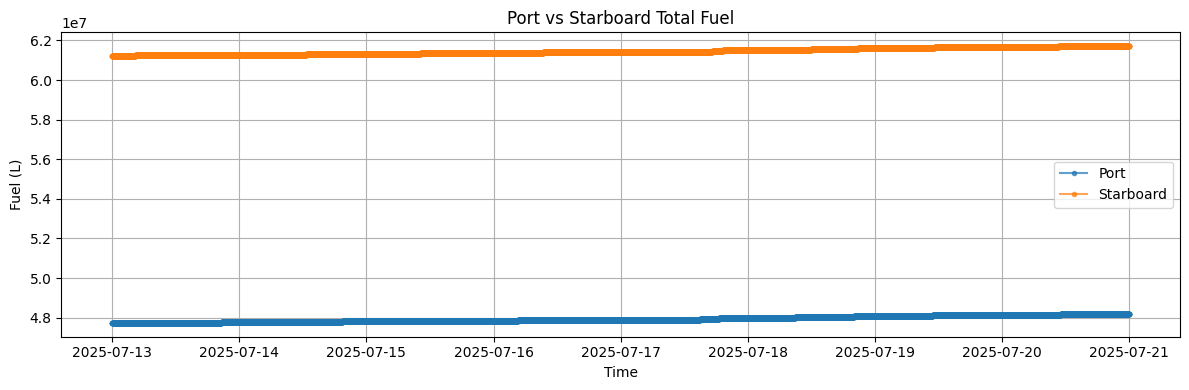

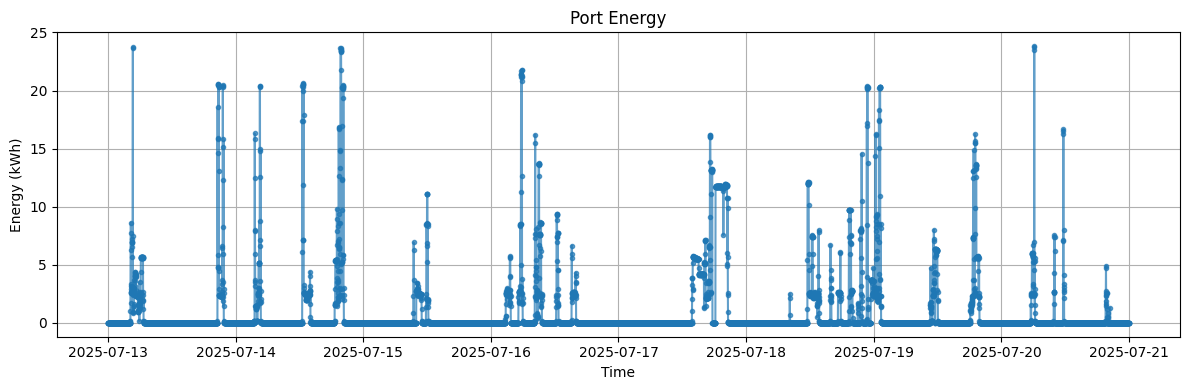

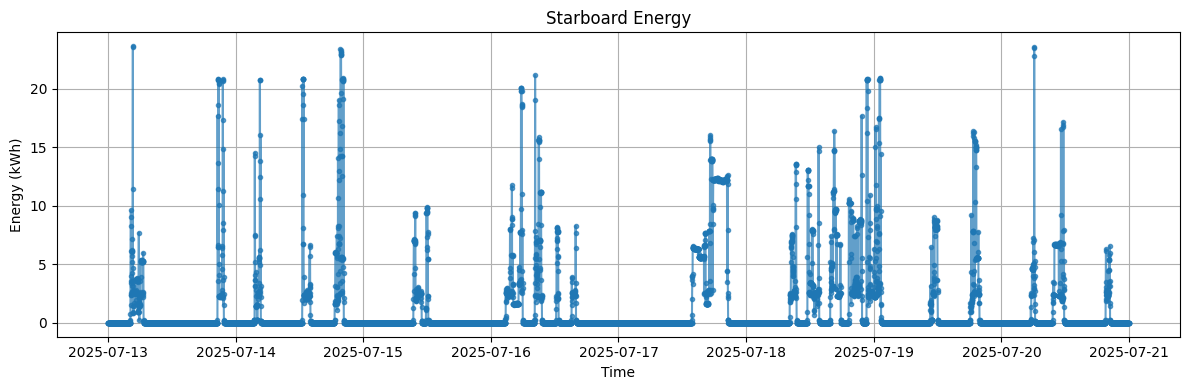

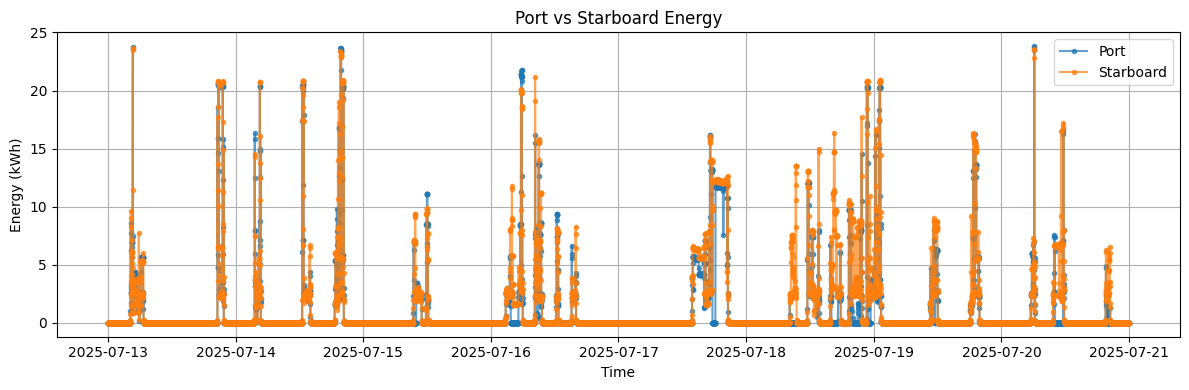

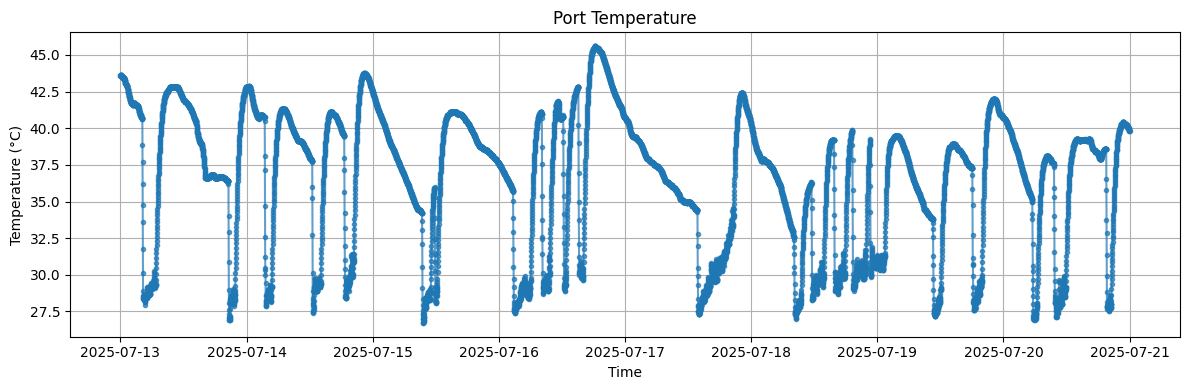

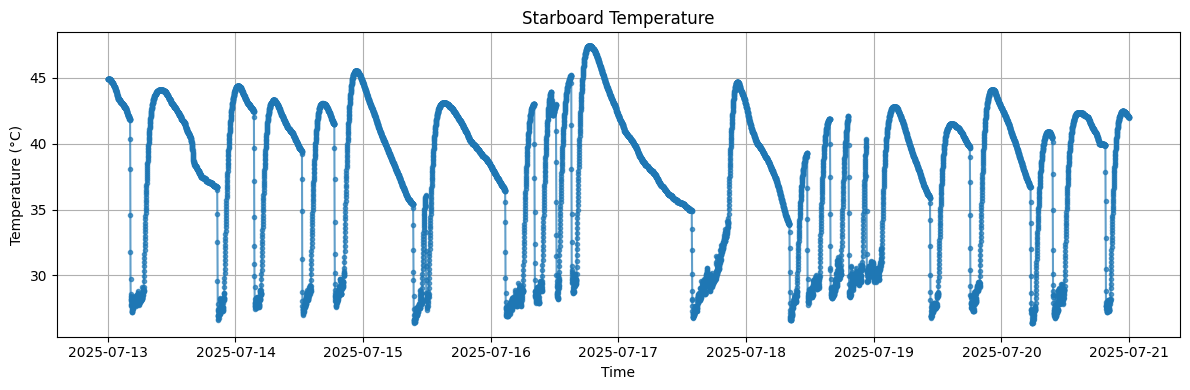

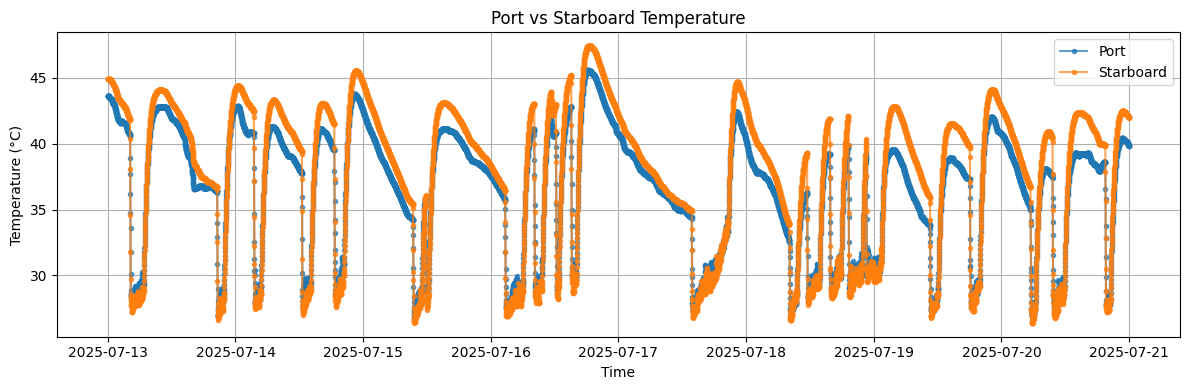


Correlation matrix of key metrics:
                        M/E PORT - Total Fuel  M/E STBD - Total Fuel  Energy_Port_kWh  Energy_STBD_kWh  \
M/E PORT - Total Fuel                1.000000               0.999800         0.002807         0.061342   
M/E STBD - Total Fuel                0.999800               1.000000         0.002490         0.060937   
Energy_Port_kWh                      0.002807               0.002490         1.000000         0.888800   
Energy_STBD_kWh                      0.061342               0.060937         0.888800         1.000000   
M/E PORT - Temperature              -0.186935              -0.186309        -0.480210        -0.585474   
M/E STBD - Temperature              -0.112676              -0.111764        -0.491290        -0.596352   

                        M/E PORT - Temperature  M/E STBD - Temperature  
M/E PORT - Total Fuel                -0.186935               -0.112676  
M/E STBD - Total Fuel                -0.186309               -0.111764  
En

In [127]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# Load cleaned merged dataset
# --------------------------
merged_file = "data/processed/Integrated_OSG_DAT_Cleaned.csv"
merged_df = pd.read_csv(merged_file)

# Set datetime index
if 'Unnamed: 0' in merged_df.columns:
    merged_df = merged_df.set_index('Unnamed: 0')
merged_df.index = pd.to_datetime(merged_df.index)

# --------------------------
# 1️⃣ Check time differences & duplicates
# --------------------------
time_diffs = merged_df.index.to_series().diff().dt.total_seconds()
print("Unique time differences (seconds):", time_diffs.unique())
missing_steps = time_diffs.ne(60).sum()
duplicates = merged_df.index.duplicated().sum()
print(f"Missing or irregular timestamps: {missing_steps}")
print(f"Duplicated timestamps: {duplicates}\n")

# --------------------------
# 2️⃣ Sample rows for spot check
# --------------------------
sample_times = ['2025-07-13 12:00:00', '2025-07-15 08:15:00']
print("Sample rows:")
print(merged_df.loc[sample_times])

# --------------------------
# 3️⃣ Summary statistics
# --------------------------
print("\nNumeric summary statistics:")
print(merged_df.select_dtypes(include=['float64','int64']).describe())

# Check missing values
missing_vals = merged_df.isna().sum()
print("\nMissing values per column:")
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "✅ No missing values detected.")

# --------------------------
# 4️⃣ Function to plot time series
# --------------------------
def plot_series(df, column, title, ylabel=None):
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df[column], marker='.', linestyle='-', alpha=0.7)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel if ylabel else column)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --------------------------
# 5️⃣ Port vs Starboard comparison
# --------------------------
def compare_port_stbd(df, port_col, stbd_col, title, ylabel):
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df[port_col], label='Port', marker='.', linestyle='-', alpha=0.7)
    plt.plot(df.index, df[stbd_col], label='Starboard', marker='.', linestyle='-', alpha=0.7)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --------------------------
# 6️⃣ Plot key variables
# --------------------------
# Fuel
plot_series(merged_df, 'M/E PORT - Total Fuel', "Port Total Fuel", "Fuel (L)")
plot_series(merged_df, 'M/E STBD - Total Fuel', "Starboard Total Fuel", "Fuel (L)")
compare_port_stbd(merged_df, 'M/E PORT - Total Fuel', 'M/E STBD - Total Fuel', "Port vs Starboard Total Fuel", "Fuel (L)")

# Energy
plot_series(merged_df, 'Energy_Port_kWh', "Port Energy", "Energy (kWh)")
plot_series(merged_df, 'Energy_STBD_kWh', "Starboard Energy", "Energy (kWh)")
compare_port_stbd(merged_df, 'Energy_Port_kWh', 'Energy_STBD_kWh', "Port vs Starboard Energy", "Energy (kWh)")

# Temperature
plot_series(merged_df, 'M/E PORT - Temperature', "Port Temperature", "Temperature (°C)")
plot_series(merged_df, 'M/E STBD - Temperature', "Starboard Temperature", "Temperature (°C)")
compare_port_stbd(merged_df, 'M/E PORT - Temperature', 'M/E STBD - Temperature', "Port vs Starboard Temperature", "Temperature (°C)")

# --------------------------
# 7️⃣ Correlation matrix for numeric columns
# --------------------------
corr_cols = ['M/E PORT - Total Fuel','M/E STBD - Total Fuel',
             'Energy_Port_kWh','Energy_STBD_kWh',
             'M/E PORT - Temperature','M/E STBD - Temperature']
corr_matrix = merged_df[corr_cols].corr()
print("\nCorrelation matrix of key metrics:")
print(corr_matrix)
